# Discounting and WACC

Discounting turns future cash flows into today's value. WACC, the Weighted Average Cost of Capital, is one of the most common discount rates used in company valuation.

Abbreviations used in this notebook:

- **WACC**: Weighted Average Cost of Capital, the blended required return of debt and equity investors.
- **CAPM**: Capital Asset Pricing Model, a formula for estimating the cost of equity.
- **DCF**: Discounted Cash Flow, a valuation method that discounts future free cash flows.
- **FCF**: Free Cash Flow, cash generated by the business after capital expenditures.
- **PV**: Present Value, today's value of a future cash flow.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

A company is usually financed by a mix of equity and debt:

- **Equity investors** expect a return because they take ownership risk.
- **Debt investors** expect interest because they lend capital.

WACC blends these required returns into one rate. In a DCF, WACC is the rate used to discount free cash flows to the firm.

A lower WACC increases valuation because future cash flows are discounted less heavily. A higher WACC lowers valuation because investors require more compensation for risk.

## 2. Mathematics

**Cost of equity using CAPM, the Capital Asset Pricing Model:**

$$
r_e = r_f + \beta \times (r_m - r_f)
$$

Where:

- $r_e$ = cost of equity
- $r_f$ = risk-free rate
- $r_m$ = expected market return
- $\beta$ = beta, sensitivity of the stock's returns to market returns

> Beta is not the same as volatility. Volatility measures total return variation; beta measures the part of risk linked to broad market movements. A higher beta increases the CAPM cost of equity because shareholders require more compensation for market risk.

**After-tax cost of debt:**

$$
r_d^{after-tax} = r_d(1 - T_c)
$$

Where:

- $r_d^{after-tax}$ = after-tax cost of debt
- $r_d$ = pre-tax cost of debt
- $T_c$ = corporate tax rate

**WACC, the Weighted Average Cost of Capital:**

$$
WACC = \frac{E}{D + E}r_e + \frac{D}{D + E}r_d(1 - T_c)
$$

Where:

- $WACC$ = weighted average cost of capital
- $E$ = market value of equity
- $D$ = market value of debt
- $\frac{E}{D + E}$ = equity weight in the capital structure
- $\frac{D}{D + E}$ = debt weight in the capital structure
- $r_e$ = cost of equity
- $r_d$ = pre-tax cost of debt
- $T_c$ = corporate tax rate

**Discounting future free cash flow:**

$$
PV = \frac{FCF_t}{(1 + WACC)^t}
$$

Where:

- $FCF_t$ = free cash flow in period $t$
- $PV$ = present value
- $WACC$ = weighted average cost of capital
- $t$ = time period index

**Present value of explicit free cash flows:**

$$
PV_{explicit} = \sum_{t=1}^{N} \frac{FCF_t}{(1 + WACC)^t}
$$

Where:

- $PV_{explicit}$ = present value of free cash flows during the explicit forecast period
- $FCF_t$ = free cash flow in period $t$
- $WACC$ = weighted average cost of capital, used as the discount rate
- $N$ = number of explicit forecast periods
- $t$ = time period index

**Terminal value:**

$$
TV = \frac{FCF_N \times (1 + g)}{WACC - g}
$$

Where:

- $TV$ = terminal value after the explicit forecast period
- $FCF_N$ = free cash flow in the final explicit forecast period
- $g$ = long-term growth rate
- $WACC$ = weighted average cost of capital

**Present value of terminal value:**

$$
PV_{terminal} = \frac{TV}{(1 + WACC)^N}
$$

Where:

- $PV_{terminal}$ = present value of the terminal value
- $TV$ = terminal value after the explicit forecast period
- $WACC$ = weighted average cost of capital
- $N$ = number of explicit forecast periods

**Enterprise value sensitivity:**

$$
EV(WACC) = PV_{explicit} + PV_{terminal}
$$

Where:

- $EV(WACC)$ = enterprise value calculated at a selected WACC assumption
- $PV_{explicit}$ = present value of explicit forecast free cash flows
- $PV_{terminal}$ = present value of the terminal value
- $WACC$ = discount rate varied across the sensitivity range


## 3. Implementation

We will estimate WACC for a mature, defensive company profile. The assumptions are synthetic, but the model structure is the same one used in valuation work.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format


def cost_of_equity(risk_free_rate, beta, equity_risk_premium):
    return risk_free_rate + beta * equity_risk_premium


def after_tax_cost_of_debt(pre_tax_cost_of_debt, tax_rate):
    return pre_tax_cost_of_debt * (1 - tax_rate)


def weighted_average_cost_of_capital(equity_value, debt_value, cost_equity, cost_debt, tax_rate):
    total_capital = equity_value + debt_value
    equity_weight = equity_value / total_capital
    debt_weight = debt_value / total_capital

    return equity_weight * cost_equity + debt_weight * after_tax_cost_of_debt(cost_debt, tax_rate)


def present_value(cash_flow, discount_rate, year):
    return cash_flow / (1 + discount_rate) ** year

In [2]:
assumptions = {
    "risk_free_rate": 0.015,
    "beta": 0.70,
    "equity_risk_premium": 0.055,
    "pre_tax_cost_of_debt": 0.032,
    "tax_rate": 0.21,
    "equity_value": 250_000,
    "debt_value": 45_000,
}

re = cost_of_equity(
    assumptions["risk_free_rate"],
    assumptions["beta"],
    assumptions["equity_risk_premium"],
)

wacc = weighted_average_cost_of_capital(
    assumptions["equity_value"],
    assumptions["debt_value"],
    re,
    assumptions["pre_tax_cost_of_debt"],
    assumptions["tax_rate"],
)

capital_structure = pd.DataFrame({
    "source": ["Equity", "Debt"],
    "market_value": [assumptions["equity_value"], assumptions["debt_value"]],
})
capital_structure["weight"] = capital_structure["market_value"] / capital_structure["market_value"].sum()
capital_structure["cost"] = [re, assumptions["pre_tax_cost_of_debt"]]
capital_structure["after_tax_cost"] = [re, after_tax_cost_of_debt(assumptions["pre_tax_cost_of_debt"], assumptions["tax_rate"])]
capital_structure["wacc_contribution"] = capital_structure["weight"] * capital_structure["after_tax_cost"]

print(f"Cost of equity: {re:.2%}")
print(f"After-tax cost of debt: {capital_structure.loc[1, 'after_tax_cost']:.2%}")
print(f"WACC: {wacc:.2%}")

capital_structure.style.format({
    "market_value": "CHF {:,.0f}m",
    "weight": "{:.1%}",
    "cost": "{:.2%}",
    "after_tax_cost": "{:.2%}",
    "wacc_contribution": "{:.2%}",
})

Cost of equity: 5.35%
After-tax cost of debt: 2.53%
WACC: 4.92%


,source,market_value,weight,cost,after_tax_cost,wacc_contribution
0,Equity,"CHF 250,000m",84.7%,5.35%,5.35%,4.53%
1,Debt,"CHF 45,000m",15.3%,3.20%,2.53%,0.39%


The equity contribution dominates for companies funded mostly by equity. Debt is usually cheaper because lenders have priority over shareholders and interest is tax-deductible in many jurisdictions.

In [3]:
cash_flows = pd.DataFrame({
    "year": [1, 2, 3, 4, 5],
    "free_cash_flow": [10_400, 10_800, 11_200, 11_650, 12_100],
})

cash_flows["present_value"] = cash_flows.apply(
    lambda row: present_value(row["free_cash_flow"], wacc, row["year"]),
    axis=1,
)

cash_flows.style.format({
    "year": "{:,.0f}",
    "free_cash_flow": "CHF {:,.0f}m",
    "present_value": "CHF {:,.0f}m",
})

,year,free_cash_flow,present_value
0,1,"CHF 10,400m","CHF 9,912m"
1,2,"CHF 10,800m","CHF 9,811m"
2,3,"CHF 11,200m","CHF 9,697m"
3,4,"CHF 11,650m","CHF 9,614m"
4,5,"CHF 12,100m","CHF 9,517m"


## 4. Visualization

WACC affects valuation through discounting. The same cash flow is worth less today when the discount rate is higher.

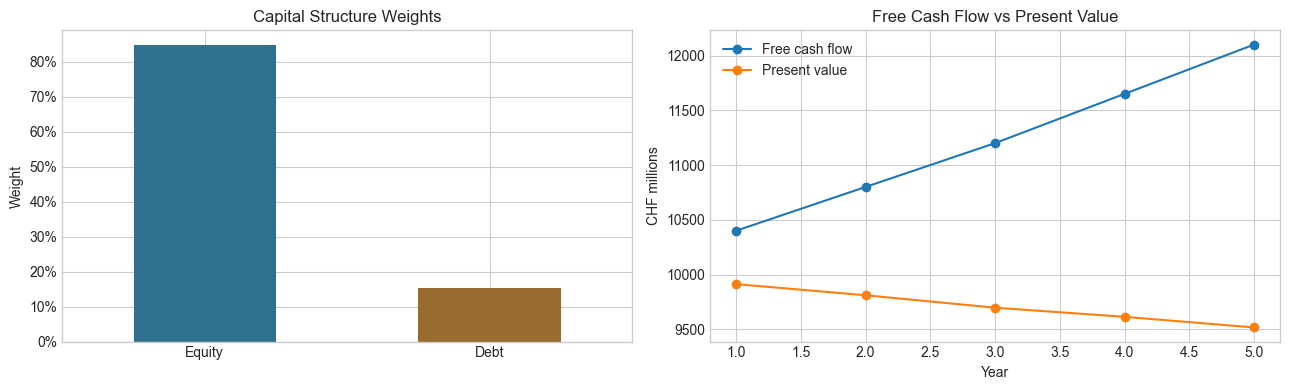

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

capital_structure.plot(
    x="source",
    y="weight",
    kind="bar",
    ax=axes[0],
    legend=False,
    color=["#2f6f8f", "#9a6b2f"],
)
axes[0].set_title("Capital Structure Weights")
axes[0].set_xlabel("")
axes[0].set_ylabel("Weight")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].tick_params(axis="x", rotation=0)

cash_flows.plot(x="year", y=["free_cash_flow", "present_value"], marker="o", ax=axes[1])
axes[1].set_title("Free Cash Flow vs Present Value")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("CHF millions")
axes[1].legend(["Free cash flow", "Present value"])

plt.tight_layout()
plt.show()

In [5]:
wacc_range = np.linspace(0.04, 0.09, 11)
terminal_growth = 0.02
final_fcf = cash_flows["free_cash_flow"].iloc[-1]

valuation_sensitivity = []
for discount_rate in wacc_range:
    pv_explicit = sum(
        present_value(row.free_cash_flow, discount_rate, row.year)
        for row in cash_flows.itertuples(index=False)
    )
    terminal_value = final_fcf * (1 + terminal_growth) / (discount_rate - terminal_growth)
    pv_terminal = terminal_value / (1 + discount_rate) ** cash_flows["year"].iloc[-1]
    valuation_sensitivity.append({
        "wacc": discount_rate,
        "pv_explicit_fcfs": pv_explicit,
        "pv_terminal_value": pv_terminal,
        "enterprise_value": pv_explicit + pv_terminal,
    })

valuation_sensitivity = pd.DataFrame(valuation_sensitivity)
valuation_sensitivity.style.format({
    "wacc": "{:.1%}",
    "pv_explicit_fcfs": "CHF {:,.0f}m",
    "pv_terminal_value": "CHF {:,.0f}m",
    "enterprise_value": "CHF {:,.0f}m",
})

,wacc,pv_explicit_fcfs,pv_terminal_value,enterprise_value
0,4.0%,"CHF 49,846m","CHF 507,211m","CHF 557,057m"
1,4.5%,"CHF 49,135m","CHF 396,154m","CHF 445,289m"
2,5.0%,"CHF 48,441m","CHF 322,343m","CHF 370,783m"
3,5.5%,"CHF 47,761m","CHF 269,808m","CHF 317,570m"
4,6.0%,"CHF 47,097m","CHF 230,567m","CHF 277,663m"
5,6.5%,"CHF 46,446m","CHF 200,182m","CHF 246,628m"
6,7.0%,"CHF 45,810m","CHF 175,994m","CHF 221,804m"
7,7.5%,"CHF 45,187m","CHF 156,308m","CHF 201,495m"
8,8.0%,"CHF 44,578m","CHF 139,996m","CHF 184,574m"
9,8.5%,"CHF 43,981m","CHF 126,277m","CHF 170,258m"


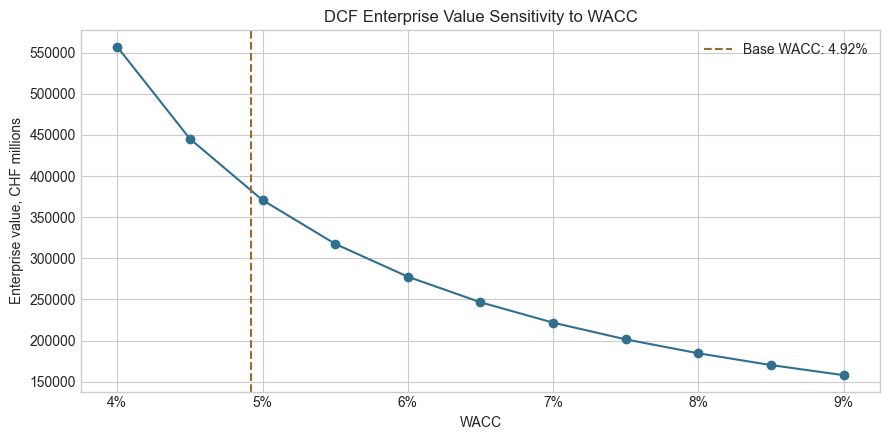

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    valuation_sensitivity["wacc"],
    valuation_sensitivity["enterprise_value"],
    marker="o",
    color="#2f6f8f",
)
ax.axvline(wacc, color="#9a6b2f", linestyle="--", label=f"Base WACC: {wacc:.2%}")
ax.set_title("DCF Enterprise Value Sensitivity to WACC")
ax.set_xlabel("WACC")
ax.set_ylabel("Enterprise value, CHF millions")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Application

WACC is used as the discount rate for free cash flows to the firm in a DCF model. It combines market risk, capital structure, borrowing cost, and tax effects into one required return.

When estimating WACC for a real company, ask:

- Is beta stable, or does it reflect temporary market stress?
- Is the risk-free rate matched to the currency of the cash flows?
- Is the equity risk premium reasonable for the market?
- Is debt measured at market value or book value?
- Is the target capital structure more relevant than the current structure?

For mature companies, a small WACC change can shift valuation materially because much of the value comes from long-dated cash flows and terminal value.

In [7]:
base_ev = valuation_sensitivity.loc[np.isclose(valuation_sensitivity["wacc"], 0.065), "enterprise_value"]
low_wacc_ev = valuation_sensitivity.loc[valuation_sensitivity["wacc"].idxmin(), "enterprise_value"]
high_wacc_ev = valuation_sensitivity.loc[valuation_sensitivity["wacc"].idxmax(), "enterprise_value"]

print(f"Estimated WACC: {wacc:.2%}")
print(f"Enterprise value at 4% WACC: CHF {low_wacc_ev:,.0f}m")
print(f"Enterprise value at 9% WACC: CHF {high_wacc_ev:,.0f}m")
print(f"Valuation drop from 4% to 9% WACC: {(1 - high_wacc_ev / low_wacc_ev):.1%}")

Estimated WACC: 4.92%
Enterprise value at 4% WACC: CHF 557,057m
Enterprise value at 9% WACC: CHF 157,989m
Valuation drop from 4% to 9% WACC: 71.6%


## 6. Reflection

- WACC is the blended required return of equity and debt capital providers.
- Cost of equity is usually higher than cost of debt because shareholders take more risk.
- The tax shield makes after-tax debt cheaper than pre-tax debt.
- WACC should match the risk, currency, and capital structure of the cash flows being discounted.
- Valuation is highly sensitive to WACC, especially when terminal value is large.

Questions to answer after running the notebook:

1. Why does a higher WACC reduce present value?
2. Why is cost of equity usually higher than cost of debt?
3. What would happen to WACC if the company added much more debt?
4. Which WACC input feels most judgment-based: beta, market risk premium, cost of debt, or capital structure?